# **PRACTICE 4: DOR**

There are aggressive and non-aggressive tweets in the training and validation files, as well as their labels. Here, an example of classification is given.

## **Repeat the first part of the last practice:**

In [1]:
# Libraries.
import numpy as np                               # library for numerical operations.
import matplotlib.pyplot as plt                  # library for plotting.          
import nltk                                      # library for text processing.
from collections import Counter                  # library for counting.
from nltk.tokenize import TweetTokenizer         # library for tokenizing.
from sklearn import svm, metrics, preprocessing  # library for support vector machine, metrics, and preprocessing.
from sklearn.model_selection import GridSearchCV # library for hyperparameter tuning.
import seaborn as sns                            # library for plotting.
from collections import defaultdict              # library for counting.
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix # library for evaluation.
from sklearn.feature_selection import SelectKBest, chi2 # library for feature selection.
from sklearn.manifold import TSNE                # library for t-SNE.
from nltk.corpus import stopwords                # library for stopwords.
from pathlib import Path                         # library for file path.
import seaborn as sns                            # library for plotting.
import pandas as pd                              # library for data manipulation.

# Function to read the text and labels from the files.
def get_text_from_file(corpus_path: Path, labels_path: Path) -> tuple[list[str]]:
    """
    Read the text and labels from the files.

    Parameters
    ----------
    corpus_path : Path
        The path to the file containing the text.
    labels_path : Path
        The path to the file containing the labels.

    Returns
    -------
    tuple[list[str]]
        The text and labels.
    """
    with open(corpus_path, "r") as corpus_file, open(labels_path, "r") as labels_file:
        corpus = corpus_file.readlines()                 # Read the text line by line.
        labels = list(map(int, labels_file.readlines())) # Read the labels line by line.

    return corpus, labels
# Load the data.
tr_corpus, tr_labels   = get_text_from_file('../practice3_class5/mex20_train.txt', '../practice3_class5/mex20_train_labels.txt') # Training data.
val_corpus, val_labels = get_text_from_file('../practice3_class5/mex20_val.txt', '../practice3_class5/mex20_val_labels.txt')     # Validation data.

print("    -   Entrenamiento:", len(tr_corpus))
print("    -   Validación   :", len(val_corpus))

    -   Entrenamiento: 5278
    -   Validación   : 587


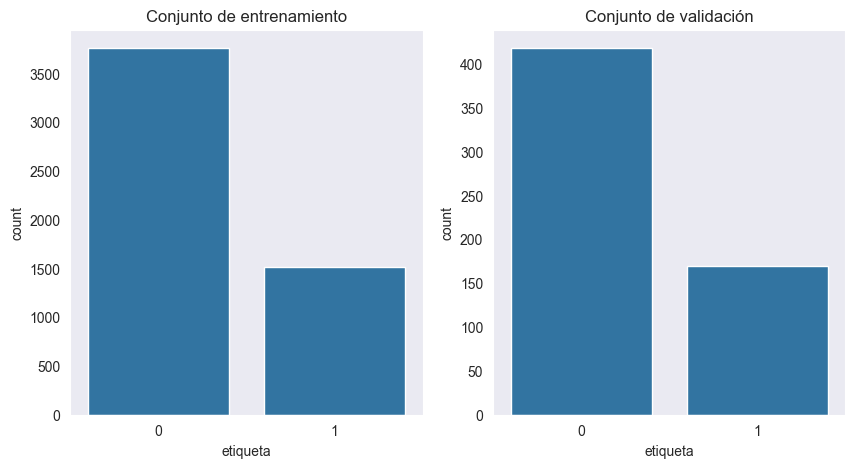

In [2]:
sns.set_style("dark") # para mejores gráficas
fig, axs = plt.subplots(1, 2, figsize = (10,5))
sns.countplot(data = pd.DataFrame(tr_labels, columns = ["etiqueta"]), x = "etiqueta", ax = axs[0])
sns.countplot(data = pd.DataFrame(val_labels, columns = ["etiqueta"]), x = "etiqueta", ax = axs[1])
axs[0].set_title("Conjunto de entrenamiento")
axs[1].set_title("Conjunto de validación")
plt.show()

In [3]:
# Tokenization and word counting.
tokenizer = TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)                                        # Create a tokenizer.
tr_corpus_tk = [tokenizer.tokenize(doc) for doc in tr_corpus]       # Tokenize the text.
fdist = nltk.FreqDist(word for doc in tr_corpus_tk for word in doc) # Frequency distribution.
print("Vocabulary size  :", len(fdist))
print("Most common words:", fdist.most_common(10))

fdist

Vocabulary size  : 13071
Most common words: [('que', 3111), ('de', 3094), (',', 3016), ('.', 2604), ('la', 2269), ('a', 2205), ('y', 2098), ('no', 1819), ('me', 1475), ('!', 1435)]


FreqDist({'que': 3111, 'de': 3094, ',': 3016, '.': 2604, 'la': 2269, 'a': 2205, 'y': 2098, 'no': 1819, 'me': 1475, '!': 1435, ...})

In [4]:
stopwords_es = set(stopwords.words("spanish"))
# Remove the stopwords from the vocabulary.
quit_stop_words = [ 
            (word, freq)
            for word, freq in fdist.most_common()
            if word not in stopwords_es
        ]
quit_stop_words # Fdist sin stopwords

[(',', 3016),
 ('.', 2604),
 ('!', 1435),
 ('verga', 802),
 ('madre', 772),
 ('?', 704),
 ('putos', 593),
 ('si', 593),
 ('"', 590),
 ('putas', 578),
 ('...', 464),
 ('😂', 434),
 ('loca', 384),
 ('gorda', 321),
 ('bien', 258),
 ('¿', 243),
 ('feas', 228),
 ('pinche', 220),
 ('puta', 213),
 (':', 208),
 ('ser', 198),
 ('puto', 196),
 ('hdp', 171),
 ('tan', 171),
 ('así', 169),
 ('…', 151),
 ('mamar', 136),
 ('q', 135),
 ('quiero', 135),
 ('solo', 134),
 ('¡', 132),
 ('<url>', 132),
 ('joto', 131),
 ('cosas', 131),
 ('marica', 131),
 ('siempre', 130),
 ('ahora', 130),
 ('hace', 128),
 ('ver', 127),
 ('vale', 126),
 ('mejor', 126),
 ('hoy', 121),
 ('gente', 120),
 ('vida', 120),
 ('️', 119),
 ('va', 116),
 ('voy', 115),
 ('pinches', 114),
 ('día', 114),
 ('jajaja', 110),
 ('vez', 103),
 ('mierda', 103),
 ('luchona', 100),
 ('😭', 99),
 ('-', 97),
 ('(', 96),
 ('pues', 95),
 (')', 95),
 ('hijo', 90),
 ('😍', 89),
 ('jajajaja', 89),
 ('alguien', 87),
 ('tontas', 85),
 ('hacer', 85),
 ('😡', 85

In [5]:
max_vocab_size = 5000
dict_indices = {
            word: idx
            for idx, (word, _) in enumerate(quit_stop_words[: 5000])
        }
top_words = set(dict_indices.keys())
print(top_words)
dict_indices

{'deje', 'ahhh', 'gordo', 'hule', 'v', 'robos', 'gusto', 'bebe', 'cargador', 'ciencias', 'guapas', 'uta', 'mañanas', 'denuncia', 'economía', 'sábado', 'panocha', 'jotitos', 'aman', 'pobre', 'chingon', 'machorra', 'diablo', 'dormido', 'quedas', 'recio', 'bueno', 'exclamó', 'perfección', 'desesperada', 'buenas', 'perversos', 'perfecta', 'dedique', '#pontelaverde', 'escucha', 'montarme', '😤', 'amig', 'putooo', 'puden', '50', 'sentimientos', 'haters', 'bancos', 'humana', 'sabroso', 'dientes', 'julio', 'amas', 'leona', 'dulce', 'vuelvan', 'solamente', 'prohíbe', 'entrenar', 'rogar', 'arreglar', 'inyectado', 'respeta', 'grosera', 'humo', 'iba', 'graves', 'tacos', 'm', 'europa', 'saquen', 'matrimonio', 'quééé', 'patrocinada', '🙆🏻', 'paraíso', 'wero', 'reportero', '👠', 'panameña', 'caigan', 'hagan', 'completamente', 'cabronas', 'pura', 'rojo', 'pierdas', 'pequeño', 'lechuga', 'itunes', 'tapan', 'estética', 'sera', 'desea', 'hahaha', 'internet', 'bukowski', 'verán', 'sabes', 'gallo', 'himno', '

{',': 0,
 '.': 1,
 '!': 2,
 'verga': 3,
 'madre': 4,
 '?': 5,
 'putos': 6,
 'si': 7,
 '"': 8,
 'putas': 9,
 '...': 10,
 '😂': 11,
 'loca': 12,
 'gorda': 13,
 'bien': 14,
 '¿': 15,
 'feas': 16,
 'pinche': 17,
 'puta': 18,
 ':': 19,
 'ser': 20,
 'puto': 21,
 'hdp': 22,
 'tan': 23,
 'así': 24,
 '…': 25,
 'mamar': 26,
 'q': 27,
 'quiero': 28,
 'solo': 29,
 '¡': 30,
 '<url>': 31,
 'joto': 32,
 'cosas': 33,
 'marica': 34,
 'siempre': 35,
 'ahora': 36,
 'hace': 37,
 'ver': 38,
 'vale': 39,
 'mejor': 40,
 'hoy': 41,
 'gente': 42,
 'vida': 43,
 '️': 44,
 'va': 45,
 'voy': 46,
 'pinches': 47,
 'día': 48,
 'jajaja': 49,
 'vez': 50,
 'mierda': 51,
 'luchona': 52,
 '😭': 53,
 '-': 54,
 '(': 55,
 'pues': 56,
 ')': 57,
 'hijo': 58,
 '😍': 59,
 'jajajaja': 60,
 'alguien': 61,
 'tontas': 62,
 'hacer': 63,
 '😡': 64,
 '“': 65,
 'toda': 66,
 'cagado': 67,
 'mas': 68,
 'gusta': 69,
 '”': 70,
 'pendejo': 71,
 'tonta': 72,
 'mamando': 73,
 'puedo': 74,
 'hijos': 75,
 '🙄': 76,
 'mal': 77,
 'nunca': 78,
 '..': 79

## **Bag of words matrix.**

In [6]:
def build_bow_binary_weights(docs: list, vocab: list, word_index: dict) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. 1 means that the word is present in the
    document and 0 means that the word is not present in the document.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.

    Returns
    -------
    np.ndarray
        Bag of words matrix.
    """
    bow = np.zeros((len(docs), len(vocab)), dtype = int) # Create a matrix of zeros.
    for i, doc in enumerate(docs):                       # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))   # Tokenize the document.
        for word in word_counts:                         # Iterate over the words.
            if word in word_index:                       # If the word is in the vocabulary.
                bow[i, word_index[word]] = 1             # Set the corresponding entry to 1.
    return bow

# Build the bag of words matrices.
BOW_tr  = build_bow_binary_weights(tr_corpus, top_words, dict_indices)  # Training data.
BOW_val = build_bow_binary_weights(val_corpus, top_words, dict_indices) # Validation data.

# Print the shape of the matrices.
print(BOW_tr.shape)
print(BOW_val.shape)

(5278, 5000)
(587, 5000)


## **Compute DOR**

This function receives an array of the docs to be processed (the bag of words). We want a term-doc array. The input bag of words is in the format of doc-term.

> La contrucción es:
>$$
>dfitf(d_k,t_j) = df(d_k,t_j) \cdot \log{\frac{|\tau|}{\#\tau(d_k)}}
>$$
> donde $\#\tau(d_k)$ denota el número de términos distintos en el
diccionario $\tau$ que aparecen al menos una vez en $d_k$ y
>$$
>df(d_k,t_j) = 1+\log{\#(d_k,t_j)} \text{ si } \#(d_k,t_j) > 0 \text{ y $0$ en otro caso.}
>$$
> donde $\#(d_k,t_j)$ es el número de veces que $t_k$ ocurre en $d_j$.

In [7]:
def compute_DOR(TR: np.ndarray, subset = None) -> np.ndarray:
    """
    Compute the Term-Document matrix using the DOR weighting scheme.

    Parameters
    ----------
    TR : np.ndarray
        Bag of words matrix.
    subset : list, optional
        List of indices of the documents to consider. The default is None.
    
    Returns
    -------
    np.ndarray
        Term-Document matrix (DOR). Rows are words and columns are documents.
    """
    # Get the subset of the documents.
    TR_subset = TR if subset is None else TR[subset]

    # Get the dimensions of the input matrix.
    n_docs, n_words = TR_subset.shape # Number of documents and words in the complete vocabulary size.

    # Create a matrix of zeros with the shape of the transpose of the bag of words matrix.
    word_counts_per_doc = np.count_nonzero(TR_subset, axis = 1) # Count the number of words per document.

    # Compute the log term frequencies.
    log_term_frequencies = np.zeros_like(TR_subset, dtype = np.float64) # Create a matrix of zeros.
    mask = TR_subset > 0                                                # Mask of the words that appear in the documents.
    log_term_frequencies[mask] = 1 + np.log(TR_subset[mask])            # Compute the log term frequencies. df_kj = 1 + log(f_kj),
                                                                        # where f_kj is the frequency of the term k in the document j.
    
    # Compute the log document ratios.
    log_document_ratios = np.log(n_docs / word_counts_per_doc).reshape(-1, 1) # log(N/n_k) where N is the number of documents and n_k is the number of documents containing the term k.

    # Compute the DOR.
    DRT = log_term_frequencies * log_document_ratios # Compute the DOR. w_ki = (1 + log(f_ki)) * log(N/n_k)

    return preprocessing.normalize(DRT.T, norm = 'l2') # Normalize the DOR matrix.

# Compute the DOR matrices.
DOR_base = compute_DOR(BOW_tr) # Compute the DOR matrix.
DOR_base.shape

(5000, 5278)

## **Feature Selection**

We use sklearn to perform feature selection. It selects the 1000 most relevant terms for the class of interest tr_y.

In [8]:
# Select the 1000 best features.
features = SelectKBest(chi2, k = 1000).fit(BOW_tr, tr_labels)

# Get the indices of the best features.
best = features.get_support(indices = True)
print(best[:15])

[ 0  2  3  4  6  8 12 13 15 16 17 18 19 21 22]


From the previously created dictionary, we exchange the indexing, that is, now the dictionary indexes will be the number and will return the word corresponding to that index

In [9]:
dict_index_inv = {}
for w in dict_indices:
    dict_index_inv[dict_indices[w]] = w

print("Some index:", dict_index_inv[32])

Some index: joto


We selected the 1000 most relevant terms using their indexes:

In [10]:
t_words = [dict_index_inv[i] for i in best]
t_words[:10]

[',', '!', 'verga', 'madre', 'putos', '"', 'loca', 'gorda', '¿', 'feas']

We select the row corresponding to each word in DOR_base.

In [11]:
t_matrix = np.array([DOR_base[dict_indices[w]] for w in t_words])
t_matrix.shape

(1000, 5278)

Here TSNE is applied to find the most relevant features projecting to $R^2$

In [12]:
reduced_matrix = TSNE(n_components = 2).fit_transform(t_matrix)
reduced_matrix.shape

(1000, 2)

Visualization

In [15]:
max_x = np.amax(reduced_matrix, axis = 0)[0]
max_y = np.amax(reduced_matrix, axis = 0)[1]

sw = set(stopwords.words('spanish'))
plt.figure(figsize = (40,40), dpi = 300)
plt.xlim(- max_x, max_x)
plt.ylim(- max_y, max_y)
plt.scatter(reduced_matrix[:,0], reduced_matrix[:,1], s = 5, color = 'black')
for idx, word in enumerate(t_words):
    x = reduced_matrix[idx,0]
    y = reduced_matrix[idx,1]
    if word in sw:
        plt.annotate(word, (x,y), color = 'red', fontsize = 8)
    else:
        plt.annotate(word, (x,y), color = 'black', fontsize = 8)

And this helps us to make visual conclusions with words of interest (and that have also been taken as important by tsne)

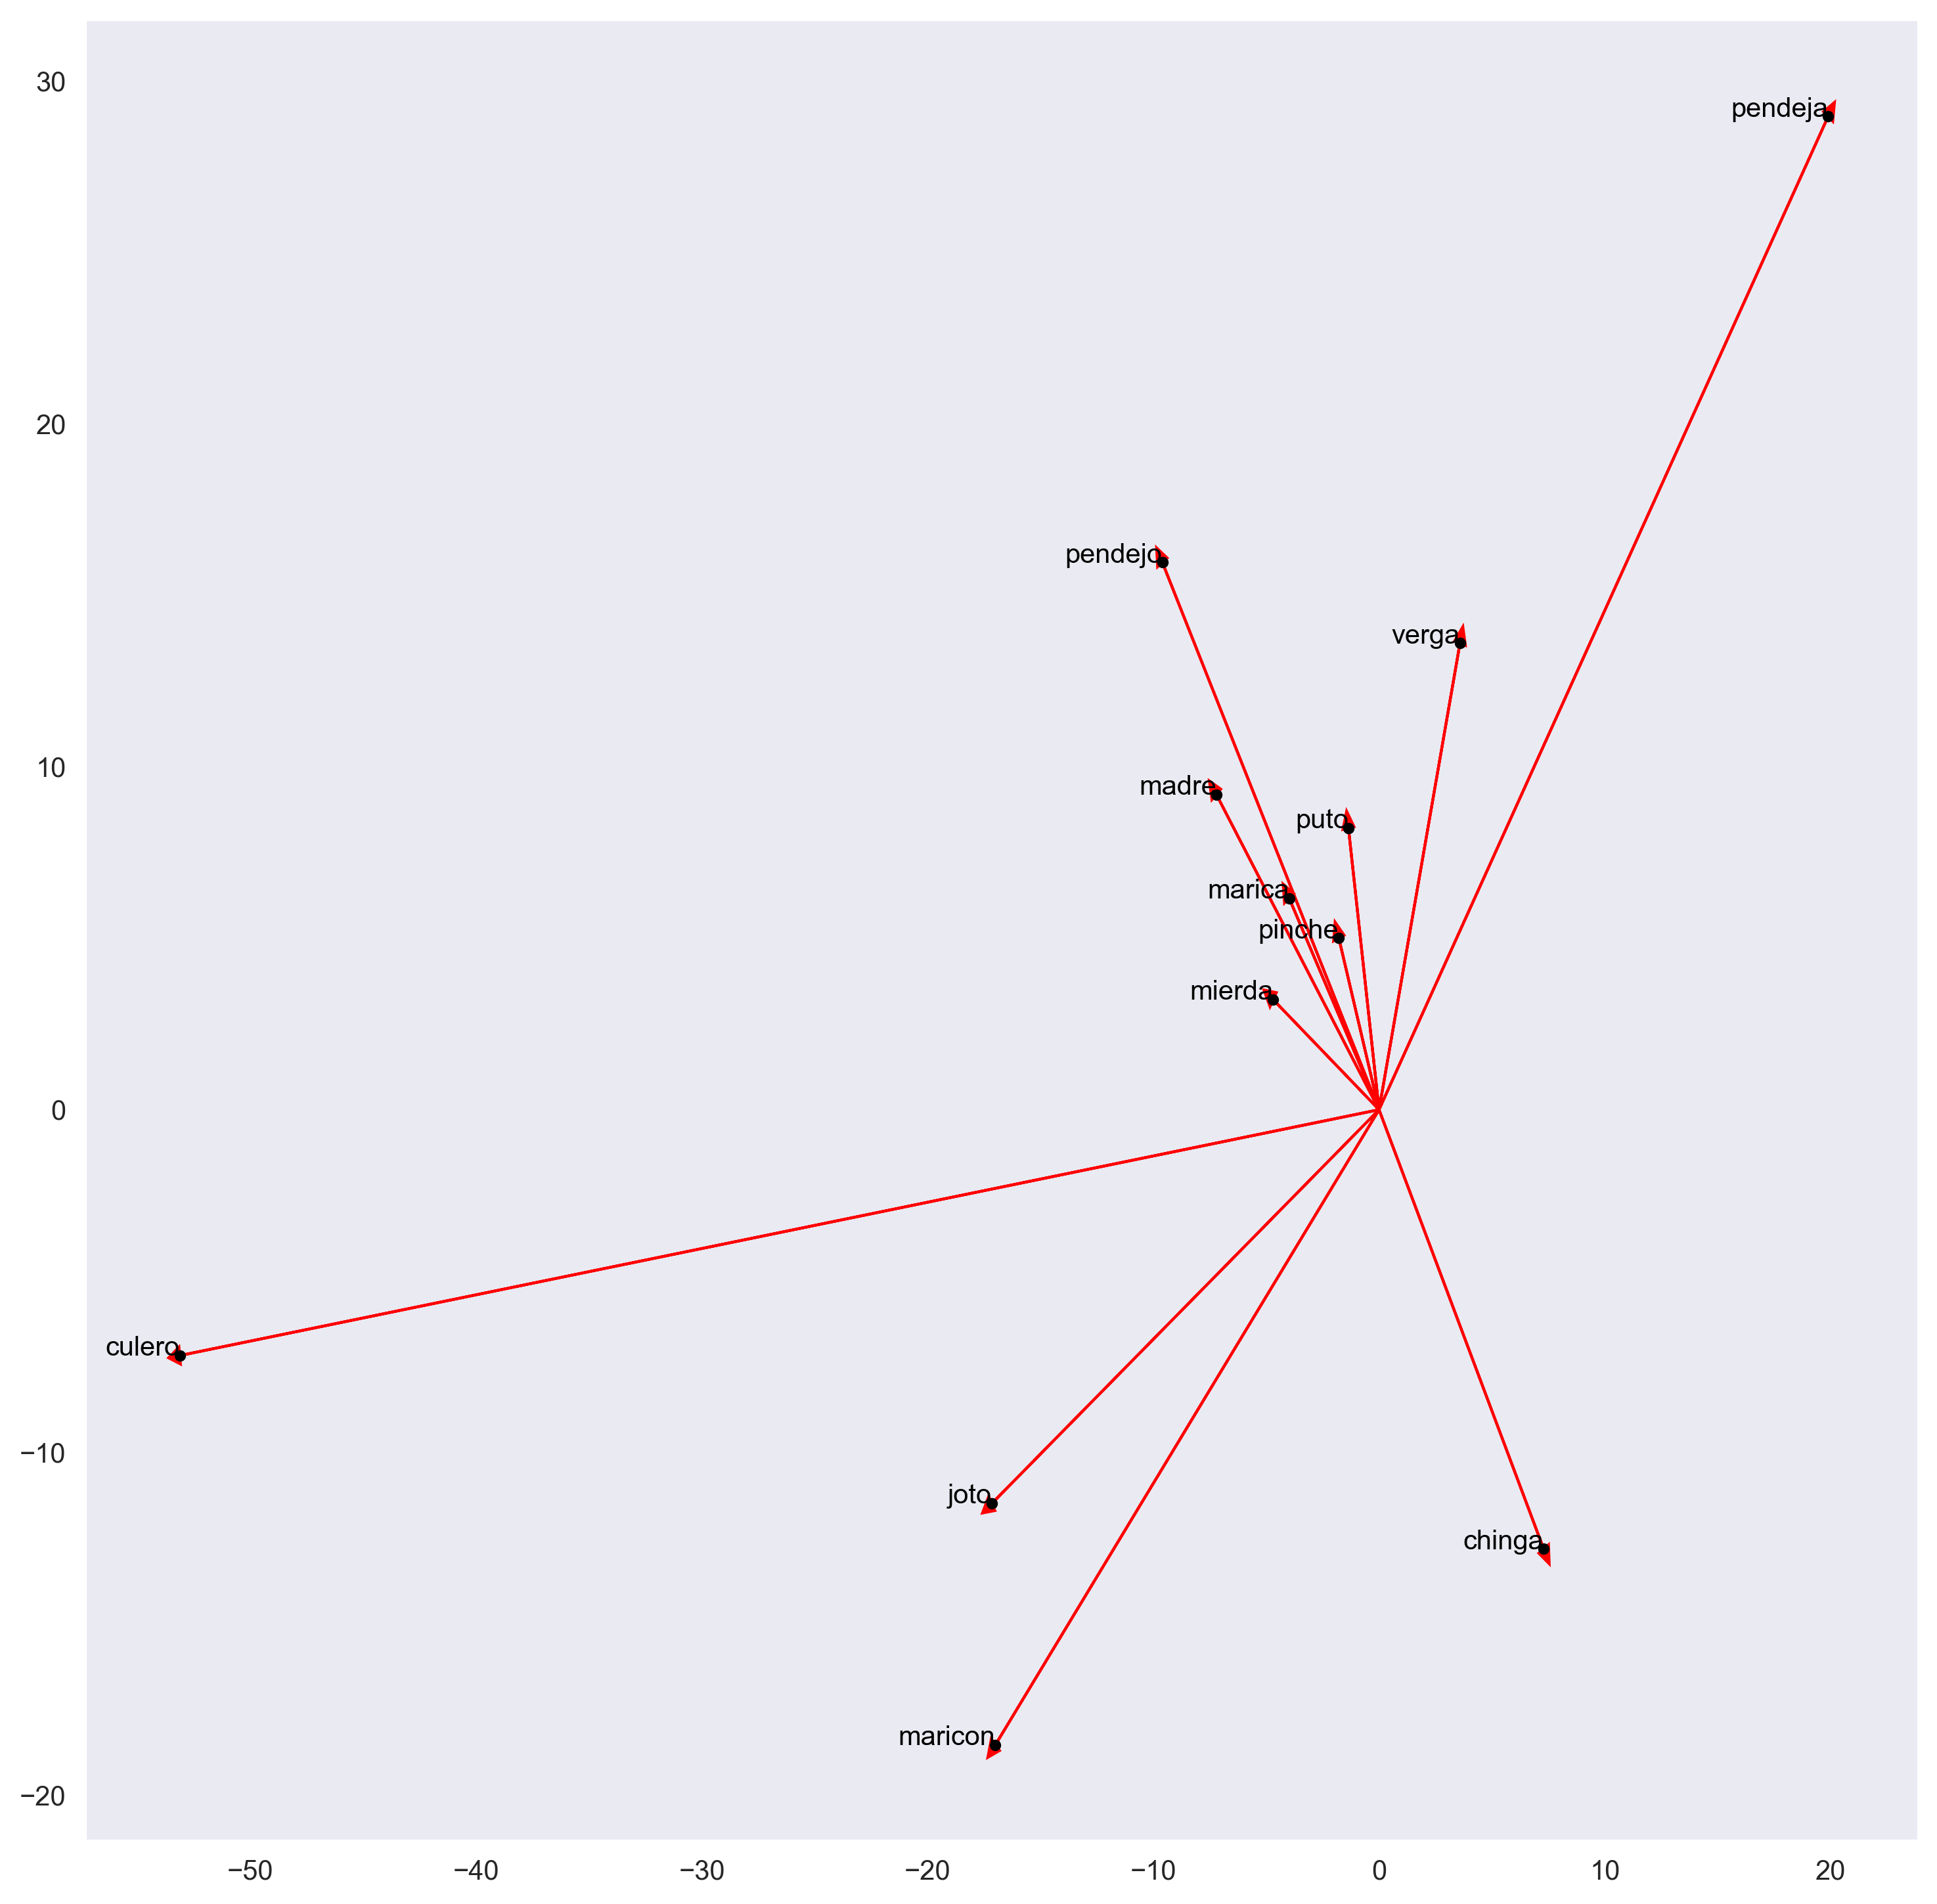

In [14]:
# Words to plot.
subsetwords = {"puto", "chinga", "madre", "verga", "pendejo", "caca", "mierda",
               "culero", "pinche", "pendeja", "joto", "jota", "marica", "maricon"}

# Filter the words to plot.
filtered_data = [(word, reduced_matrix[idx]) for word, idx in zip(t_words, range(len(t_words))) if word in subsetwords]

plotted_subsetwords, subreduced_matrix = zip(*filtered_data) if filtered_data else ([], []) # Unzip the data.
subreduced_matrix = np.array(subreduced_matrix) if subreduced_matrix else np.empty((0,2))   # Convert the data to numpy arrays.

fig, ax = plt.subplots(figsize = (12,12), dpi = 300)                                  # Create the figure.
for x, y in subreduced_matrix:                                                        # Arrows since the origin.
    ax.arrow(0, 0, x, y, head_width = 0.5, head_length = 0.5, fc = 'red', ec = 'red') # Arrow plot.
ax.scatter(subreduced_matrix[:,0], subreduced_matrix[:,1], s = 10, color = 'black')   # Scatter plot.

# Annotate the words.
for word, (x,y) in zip(plotted_subsetwords, subreduced_matrix):
    ax.annotate(word, (x,y), color = 'black', fontsize = 10, ha = 'right')

plt.show()